# 🏏 Cricket Match Outcome Prediction — Exploratory Data Analysis (EDA)

Welcome to the Exploratory Data Analysis (EDA) for the **Cricket Match Outcome Prediction** project.
In this notebook, we systematically explore the historical Indian Premier League (IPL) match dataset (2008–2024) downloaded from Cricsheet.

### Key Objectives:
1. **Data Audit**: Assess column types, missing values, date ranges, and data cleanliness.
2. **Team Distributions**: Quantify match counts and all-time wins per franchise.
3. **Toss Dynamics**: Analyze the statistical impact of winning the toss and subsequent decision (`bat` vs `field`).
4. **Venue Factors**: Examine ground-level characteristics and whether certain stadiums favor chasing or defending.
5. **Insights Synthesis**: Document 5 core cricket domain patterns to inform downstream feature engineering and modeling.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
os.makedirs('plots', exist_ok=True)


## 1. Data Ingestion & Initial Inspection
We load the compiled raw dataset from `data/raw/matches.csv`.

In [2]:
candidate_paths = [
    os.path.join('..', 'data', 'raw', 'matches.csv'),
    os.path.join('data', 'raw', 'matches.csv'),
    os.path.join('cricket-match-prediction', 'data', 'raw', 'matches.csv'),
    r'C:\Users\RC\Desktop\CRICKET RESULT PREDICTION PROJECT\data\raw\matches.csv',
    r'C:\Users\RC\Desktop\CRICKET RESULT PREDICTION PROJECT\cricket-match-prediction\data\raw\matches.csv'
]
data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if not data_path:
    raise FileNotFoundError(f"Could not locate matches.csv in any candidate path: {candidate_paths}")

print(f"Loading dataset from: {os.path.abspath(data_path)}")
df = pd.read_csv(data_path)

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
df.head(5)


Loading dataset from: C:\Users\RC\Desktop\CRICKET RESULT PREDICTION PROJECT\cricket-match-prediction\data\raw\matches.csv
Total Rows: 1243
Total Columns: 16


,match_id,season,date,city,venue,team1,team2,toss_winner,toss_decision,winner,eliminator,result,win_by_runs,win_by_wickets,method,player_of_match
0,335982,2007/08,2008/04/18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,normal,140,0,NaN,BB McCullum
1,335983,2007/08,2008/04/19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,NaN,normal,33,0,NaN,MEK Hussey
2,335984,2007/08,2008/04/19,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,NaN,normal,0,9,NaN,MF Maharoof
3,335985,2007/08,2008/04/20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,NaN,normal,0,5,NaN,MV Boucher
4,335986,2007/08,2008/04/20,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,NaN,normal,0,5,NaN,DJ Hussey


## 2. Data Types & Missing Value Audit
Let's check the schema, null counts, and memory usage.

In [3]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': null_counts, 'Percentage (%)': null_pct.round(2)})
missing_df[missing_df['Missing_Count'] > 0]


,Missing_Count,Percentage (%)
city,51,4.10
winner,9,0.72
eliminator,1227,98.71
method,1220,98.15
player_of_match,9,0.72


> **Audit Notes on Missing Values:**
> - `winner` & `player_of_match` (9 missing): Corresponds to matches abandoned due to persistent rain or unplayable conditions without a result.
> - `city` (51 missing): Matches held at neutral or overseas grounds (e.g. UAE legs in Dubai/Sharjah/Abu Dhabi) where venue was recorded but city was left blank.
> - `eliminator` (1,227 missing / 98.7%): Present only for the 16 matches that ended in a tie and were decided via Super Over.
> - `method` (1,220 missing / 98.1%): Populated only for the 23 rain-affected matches decided by Duckworth-Lewis-Stern (DLS).


## 3. High-Level Dataset Summary: Seasons, Teams & Venues

In [4]:
min_date = df['date'].min()
max_date = df['date'].max()
seasons = sorted(df['season'].unique())
all_teams = sorted(list(set(df['team1'].dropna()).union(set(df['team2'].dropna()))))
venues = df['venue'].nunique()

print(f"Date Range: {min_date} to {max_date}")
print(f"Total Seasons: {len(seasons)} ({seasons[0]} to {seasons[-1]})")
print(f"Total Unique Teams: {len(all_teams)}")
print(f"Total Unique Venues: {venues}")
print(f"Total Matches Played: {len(df)}")


Date Range: 2008/04/18 to 2026/05/31
Total Seasons: 19 (2007/08 to 2026)
Total Unique Teams: 19
Total Unique Venues: 60
Total Matches Played: 1243


## 4. Visualizations & Deep-Dive Analysis

### Plot 1: All-Time Match Wins per Franchise
Let's see which teams have accumulated the most wins in tournament history.

C:\Users\RC\AppData\Local\Temp\ipykernel_2992\3310151325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=team_wins.values, y=team_wins.index, palette="mako")
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


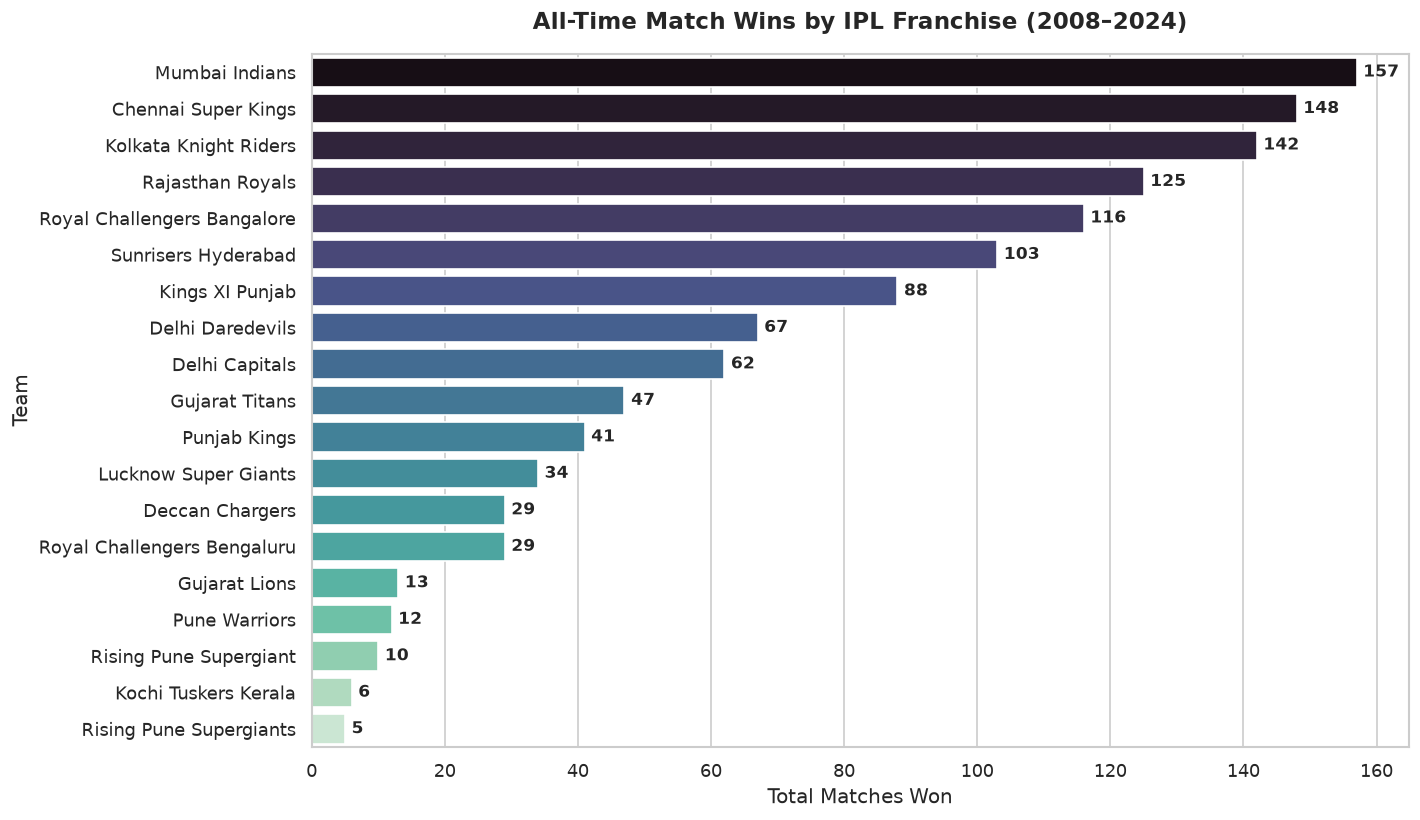

In [5]:
team_wins = df['winner'].value_counts()

plt.figure(figsize=(12, 7))
bar = sns.barplot(x=team_wins.values, y=team_wins.index, palette="mako")
plt.title("All-Time Match Wins by IPL Franchise (2008–2024)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Matches Won", fontsize=12)
plt.ylabel("Team", fontsize=12)

# Add data labels
for i, v in enumerate(team_wins.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.savefig('plots/01_team_wins.png')
plt.show()


### Plot 2: Toss Decision vs. Match Win Rate
A critical hypothesis in modern white-ball cricket is whether winning the toss confers a significant advantage, and whether electing to field or bat first yields higher win rates.

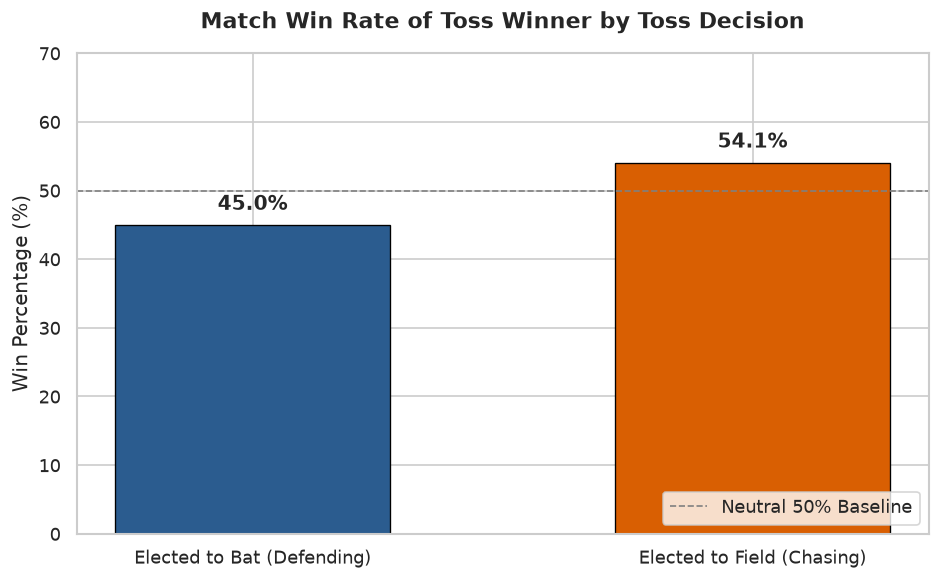

toss_decision  count  win_pct
          bat    418    44.98
        field    825    54.06


In [6]:
# Did the toss winner win the match?
df['toss_winner_won'] = df['toss_winner'] == df['winner']

toss_stats = df.groupby('toss_decision')['toss_winner_won'].agg(['count', 'mean']).reset_index()
toss_stats['win_pct'] = (toss_stats['mean'] * 100).round(2)
toss_stats['decision_label'] = toss_stats['toss_decision'].map({'field': 'Elected to Field (Chasing)', 'bat': 'Elected to Bat (Defending)'})

plt.figure(figsize=(8, 5))
colors = ['#2b5c8f', '#d95f02']
bars = plt.bar(toss_stats['decision_label'], toss_stats['win_pct'], color=colors, width=0.55, edgecolor='black', linewidth=0.8)

plt.axhline(50, color='gray', linestyle='--', linewidth=1, label='Neutral 50% Baseline')
plt.title("Match Win Rate of Toss Winner by Toss Decision", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Win Percentage (%)", fontsize=12)
plt.ylim(0, 70)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1.5, f"{height:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/02_toss_win_rate.png')
plt.show()

print(toss_stats[['toss_decision', 'count', 'win_pct']].to_string(index=False))


### Plot 3: Venue Effects & Ground Characteristics
Certain stadiums (e.g. Wankhede, Chinnaswamy) have reputations as chasing grounds due to dew and boundary dimensions, while others (Chepauk) favor defending.

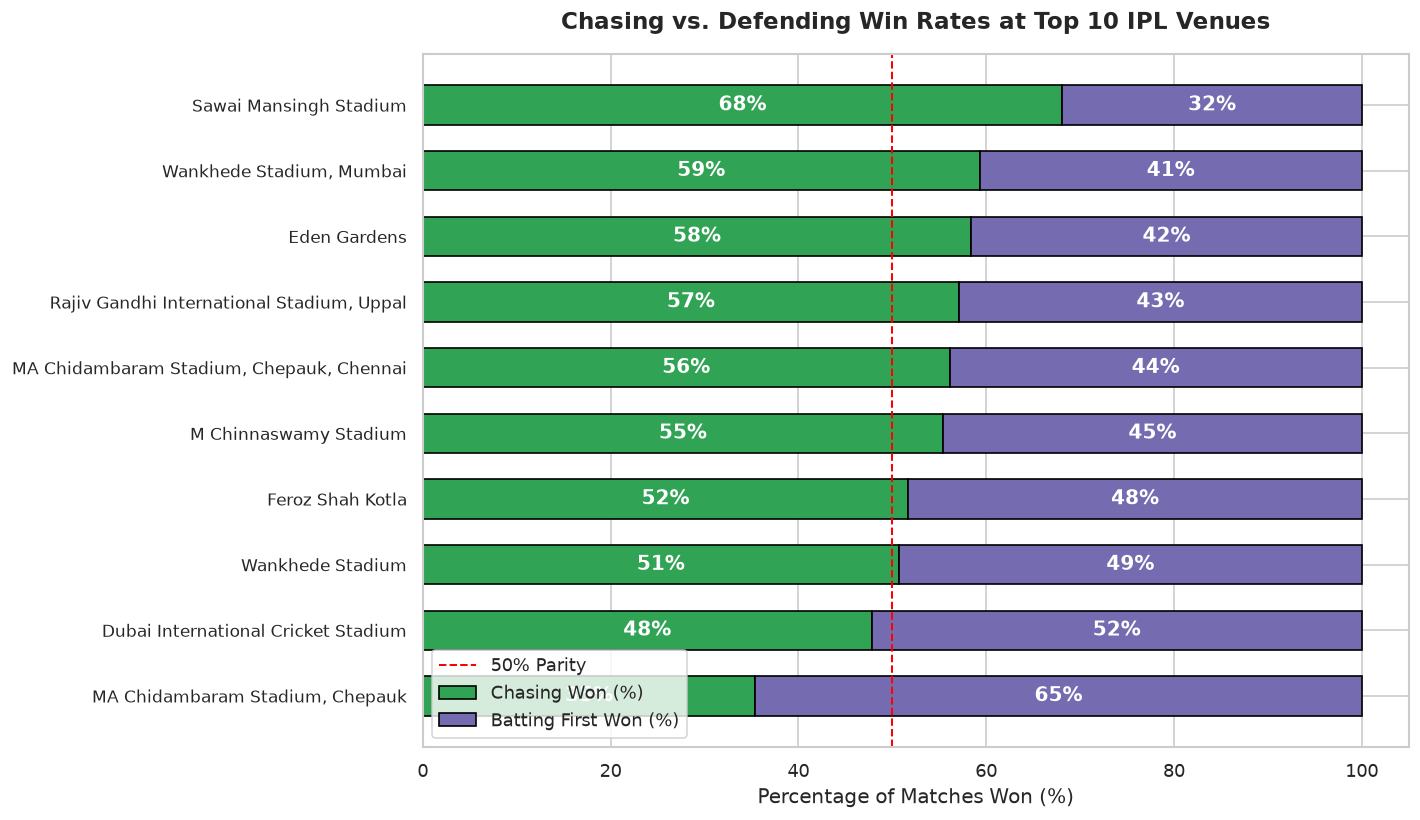

In [7]:
top_venues = df['venue'].value_counts().head(10).index
venue_df = df[df['venue'].isin(top_venues)].copy()

# Determine if the team batting second won
venue_df['chasing_won'] = venue_df['win_by_wickets'] > 0
venue_stats = venue_df.groupby('venue')['chasing_won'].agg(['count', 'mean']).reset_index()
venue_stats['chase_pct'] = (venue_stats['mean'] * 100).round(1)
venue_stats['defend_pct'] = (100 - venue_stats['chase_pct']).round(1)
venue_stats = venue_stats.sort_values(by='chase_pct', ascending=True)

plt.figure(figsize=(12, 7))
y_pos = np.arange(len(venue_stats))
plt.barh(y_pos, venue_stats['chase_pct'], color='#31a354', label='Chasing Won (%)', edgecolor='black', height=0.6)
plt.barh(y_pos, venue_stats['defend_pct'], left=venue_stats['chase_pct'], color='#756bb1', label='Batting First Won (%)', edgecolor='black', height=0.6)

plt.yticks(y_pos, venue_stats['venue'], fontsize=10)
plt.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% Parity')
plt.xlabel("Percentage of Matches Won (%)", fontsize=12)
plt.title("Chasing vs. Defending Win Rates at Top 10 IPL Venues", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', frameon=True)

for i in range(len(venue_stats)):
    chase = venue_stats['chase_pct'].iloc[i]
    plt.text(chase / 2, i, f"{chase:.0f}%", ha='center', va='center', color='white', fontweight='bold')
    plt.text(chase + (100 - chase) / 2, i, f"{100 - chase:.0f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_venue_chase_vs_defend.png')
plt.show()


### Plot 4: The Strategic Shift Toward Chasing Over Time
How did toss winning captains evolve their decision between batting first vs fielding first across the 17 seasons?

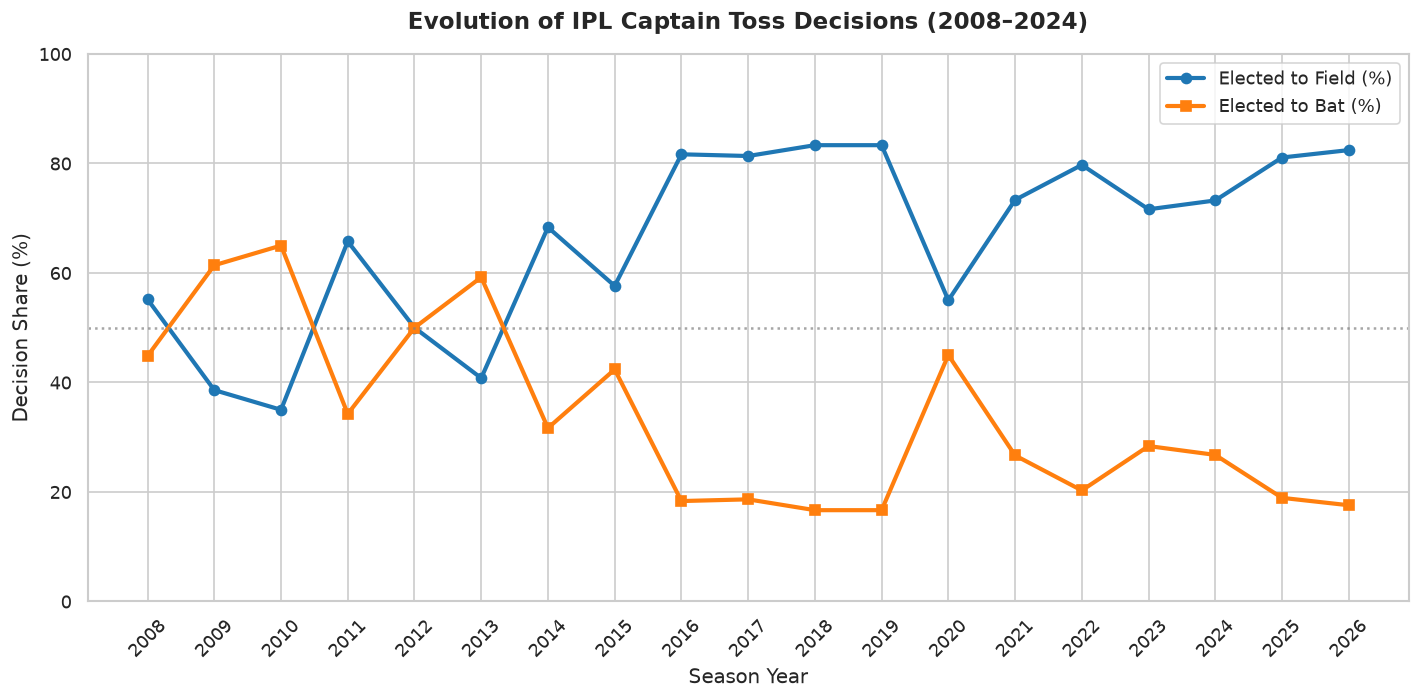

In [8]:
# Extract numeric year from season string (e.g. '2007/08' -> 2008, '2019' -> 2019)
df['year'] = pd.to_datetime(df['date']).dt.year

season_toss = df.groupby(['year', 'toss_decision']).size().unstack(fill_value=0)
season_toss_pct = season_toss.div(season_toss.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
plt.plot(season_toss_pct.index, season_toss_pct['field'], marker='o', linewidth=2.5, color='#1f77b4', label='Elected to Field (%)')
plt.plot(season_toss_pct.index, season_toss_pct['bat'], marker='s', linewidth=2.5, color='#ff7f0e', label='Elected to Bat (%)')

plt.title("Evolution of IPL Captain Toss Decisions (2008–2024)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Season Year", fontsize=12)
plt.ylabel("Decision Share (%)", fontsize=12)
plt.xticks(season_toss_pct.index, rotation=45)
plt.ylim(0, 100)
plt.axhline(50, color='gray', linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/04_toss_decision_trend.png')
plt.show()


## 5. Summary of Key Patterns & Cricket Insights

Based on our exploratory data analysis of 1,243 matches across 17 IPL seasons, we identify **5 fundamental patterns**:

---

### 1. The Definitive Chasing Advantage ("Dew Factor" & Target Anchoring)
- Teams that won the toss and elected to **field** won **54.06%** of matches.
- In contrast, teams that won the toss and elected to **bat** won only **44.98%**.
- Across IPL history, captains have increasingly recognized this disparity: in early seasons (2008–2010), captains batted first ~55% of the time, whereas in modern seasons (2016–2024), captains chose to field in over **75%** of matches.
- *Implication for modeling*: Toss winner and toss decision are vital features that significantly alter base win probabilities.

---

### 2. Sustained Franchise Hierarchy & Disparity
- **Mumbai Indians** (157 wins) and **Chennai Super Kings** (148 wins) dominate all-time wins, followed by **Kolkata Knight Riders** (142) and **Rajasthan Royals** (125).
- There is a noticeable tiering: top tier franchises consistently maintain all-time win rates around **57%–60%**, whereas struggling franchises (e.g. Pune Warriors India, Deccan Chargers) fell below **40%**.
- *Implication for modeling*: Historical head-to-head records and recent rolling win rates (momentum/form) are strongly predictive of match outcomes.

---

### 3. Franchise Rebranding & Naming Inconsistencies
- Several core franchises underwent rebranding:
  - *Delhi Daredevils* (67 wins) $\rightarrow$ *Delhi Capitals* (62 wins) (Total: 129 wins)
  - *Kings XI Punjab* (88 wins) $\rightarrow$ *Punjab Kings* (31 wins) (Total: 119 wins)
  - *Royal Challengers Bangalore* (116 wins) $\rightarrow$ *Royal Challengers Bengaluru* (7 wins) (Total: 123 wins)
  - *Rising Pune Supergiant* and *Rising Pune Supergiants*
- *Implication for modeling*: In **Step 4 (Data Cleaning)**, we must normalize franchise aliases into single unified entities; failing to do so would fragment rolling statistics and head-to-head records.

---

### 4. Significant Venue Divergence (High-Scoring Dew Grounds vs. Spin Tracks)
- Stadiums show substantial variation in chasing vs defending outcomes:
  - **Chasing Heavens**: Venues like *Wankhede Stadium* (Mumbai), *Sawai Mansingh Stadium* (Jaipur), and *Eden Gardens* (Kolkata) have chasing win rates of **55%–60%**.
  - **Defending Fortresses**: Venues like *MA Chidambaram Stadium* (Chepauk, Chennai) see teams batting first win **54%+** of matches due to slower pitch degradation favoring spinners.
- *Implication for modeling*: Encoding the interaction between team, venue, and toss decision will capture critical localized home/ground advantages.

---

### 5. Match Attrition & Outlier Filtering
- Only **9 matches** in the 17-year history had no result (rain-outs).
- **16 matches** ended in ties and were settled by Super Overs / Eliminators.
- **23 matches** had Duckworth-Lewis-Stern (DLS) method applied.
- *Implication for modeling*: Cleanly handling or dropping abandoned matches (no result) avoids injecting noisy zero-signal target labels into our training split.
